<a href="https://colab.research.google.com/github/PoisonMunna/SuperMarketSalesAnalysis/blob/main/SuperMarketSalesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Super Market Sales Analysis

## It involves initial data exploration, cleaning, and feature engineering, followed by extensive visualization to identify sales trends and patterns across various dimensions like category, region, and time. The analysis concludes with an executive summary highlighting key performance insights.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the data
df = pd.read_csv('/supermarket_sales.csv')

## Initial Data Exploration--------------------------------------------------------------------------------------------------------------------------

# 1. Look at the data
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print("First 10 rows:")
print(df.head(10))
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print("Last 10 rows:")
print(df.tail(10))
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 2. Understand the structure
print("Dataset Info:")
print(df.info())
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print(f"Dataset Shape: {df.shape}")  # (rows, columns)
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 3. Statistical summary for numerical columns
print("Statistical Summary:")
print(df.describe())
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 4. Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 5. Check unique values in categorical columns
categorical_cols = ['Category', 'Sub Category', 'City', 'Region', 'State']
for col in categorical_cols:
    if col in df.columns:
        print(f"{col}: {df[col].unique()[:10]}")  # Show first 10 unique values
print("--------------------------------------------------------------------------------------------------------------------------------------------")


--------------------------------------------------------------------------------------------------------------------------------------------
First 10 rows:
  Order ID Customer Name          Category      Sub Category            City  \
0      OD1        Harish      Oil & Masala           Masalas         Vellore   
1      OD2         Sudha         Beverages     Health Drinks     Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour      Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables      Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples            Ooty   
5      OD6        Adavan       Food Grains   Organic Staples      Dharmapuri   
6      OD7         Jonas  Fruits & Veggies  Fresh Vegetables          Trichy   
7      OD8         Hafiz  Fruits & Veggies      Fresh Fruits  Ramanadhapuram   
8      OD9         Hafiz            Bakery          Biscuits     Tirunelveli   
9     OD10      Krithika            Bakery  

## Data Cleaning and Feature Engineering


In [9]:

# 1. Convert date to datetime - handle multiple date formats
# The dataset has dates in various formats (DD-MM-YYYY, DD/MM/YYYY, M/D/YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)

# 2. Extract useful features from date
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Day'] = df['Order Date'].dt.day
df['Day_of_Week'] = df['Order Date'].dt.dayofweek  # Monday=0, Sunday=6
df['Quarter'] = df['Order Date'].dt.quarter

# 3. Create additional calculated columns
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100  # Profit percentage
df['Discount_Amount'] = df['Sales'] * df['Discount']  # Actual discount amount
df['Net_Sales'] = df['Sales'] - df['Discount_Amount']  # Sales after discount

# 4. Display the updated dataset
print("Updated Dataset with New Features:")
print(df.head(10))
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print("New Features Added:")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
print(f"Months: {sorted(df['Month'].unique())}")
print(f"Years: {sorted(df['Year'].unique())}")
print("---------------------------------------------------------------------------------------------------------------------------------------------")


Updated Dataset with New Features:
  Order ID Customer Name          Category      Sub Category            City  \
0      OD1        Harish      Oil & Masala           Masalas         Vellore   
1      OD2         Sudha         Beverages     Health Drinks     Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour      Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables      Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples            Ooty   
5      OD6        Adavan       Food Grains   Organic Staples      Dharmapuri   
6      OD7         Jonas  Fruits & Veggies  Fresh Vegetables          Trichy   
7      OD8         Hafiz  Fruits & Veggies      Fresh Fruits  Ramanadhapuram   
8      OD9         Hafiz            Bakery          Biscuits     Tirunelveli   
9     OD10      Krithika            Bakery             Cakes         Chennai   

  Order Date Region  Sales  Discount  Profit       State  Month  Year  Day  \
0 2017

## Visualization

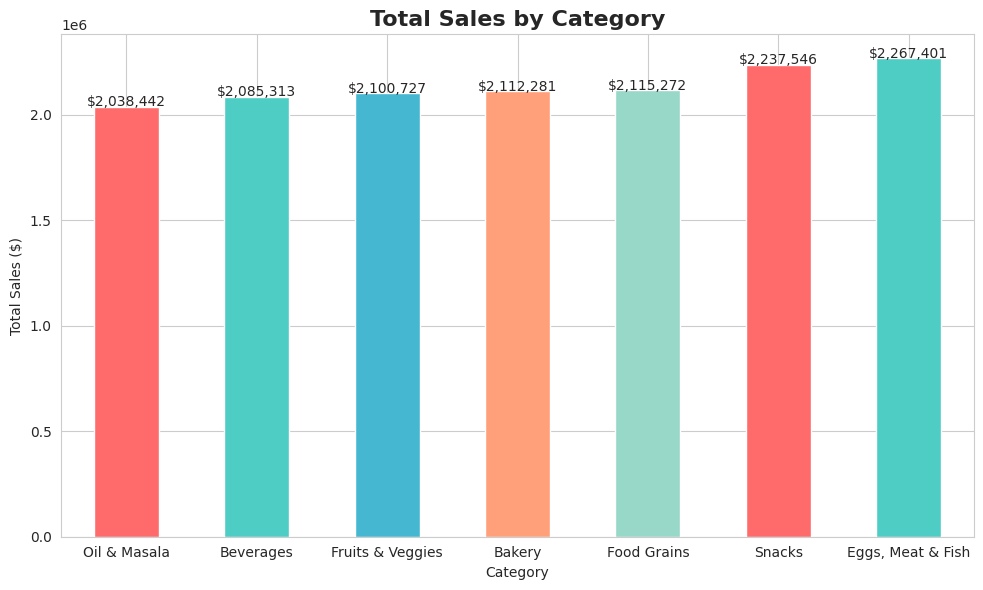

In [10]:
# A. Overall Sales Analysis
# 1. Total sales by category
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
category_sales.plot(kind='bar', color=colors[:len(category_sales)])
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
for i, v in enumerate(category_sales):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


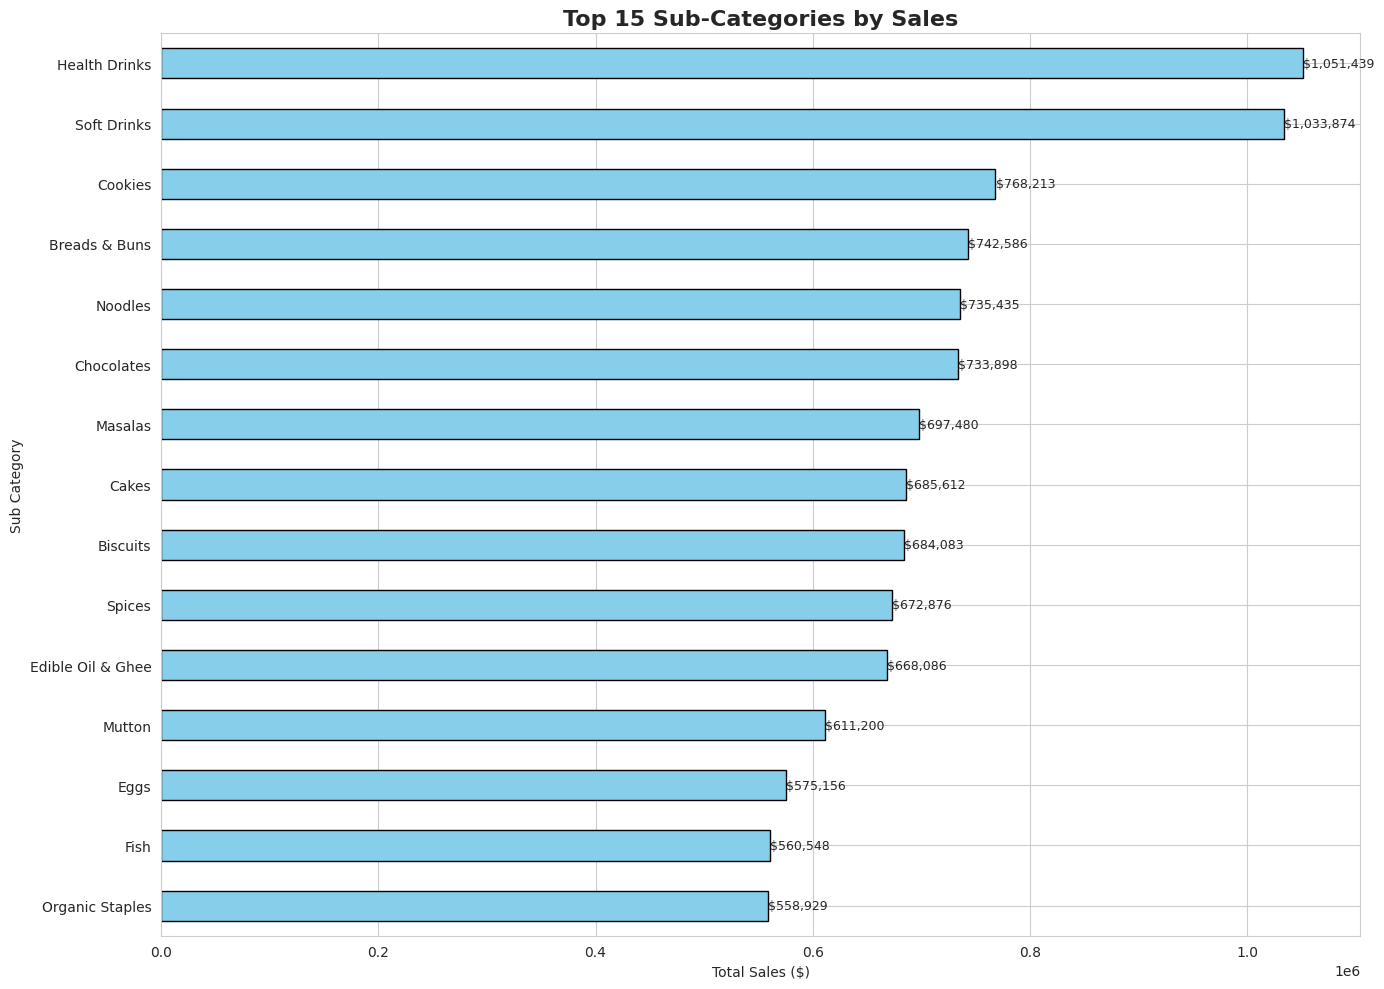

In [11]:
# 2. Sales by sub-category (top 15 to avoid clutter)
plt.figure(figsize=(14, 10))
sub_category_sales = df.groupby('Sub Category')['Sales'].sum().sort_values(ascending=True)
# Show top 15 for readability
if len(sub_category_sales) > 15:
    sub_category_sales = sub_category_sales.tail(15)
sub_category_sales.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 15 Sub-Categories by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub Category')
for i, v in enumerate(sub_category_sales):
    plt.text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

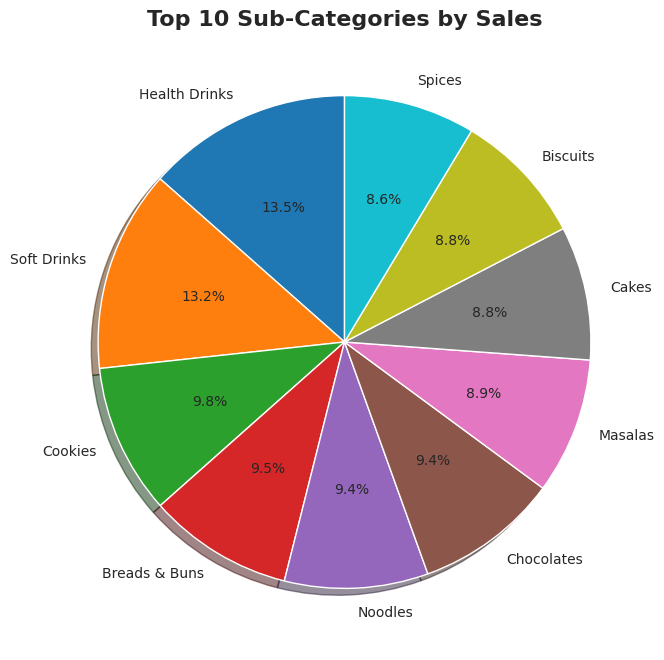

In [12]:
# 3. Top 10 sub-categories by sales (pie chart)
plt.figure(figsize=(10, 8))
top_sub_categories = df.groupby('Sub Category')['Sales'].sum().nlargest(10)
plt.pie(top_sub_categories, labels=top_sub_categories.index, autopct='%1.1f%%',
        startangle=90, shadow=True)
plt.title('Top 10 Sub-Categories by Sales', fontsize=16, fontweight='bold')
plt.show()

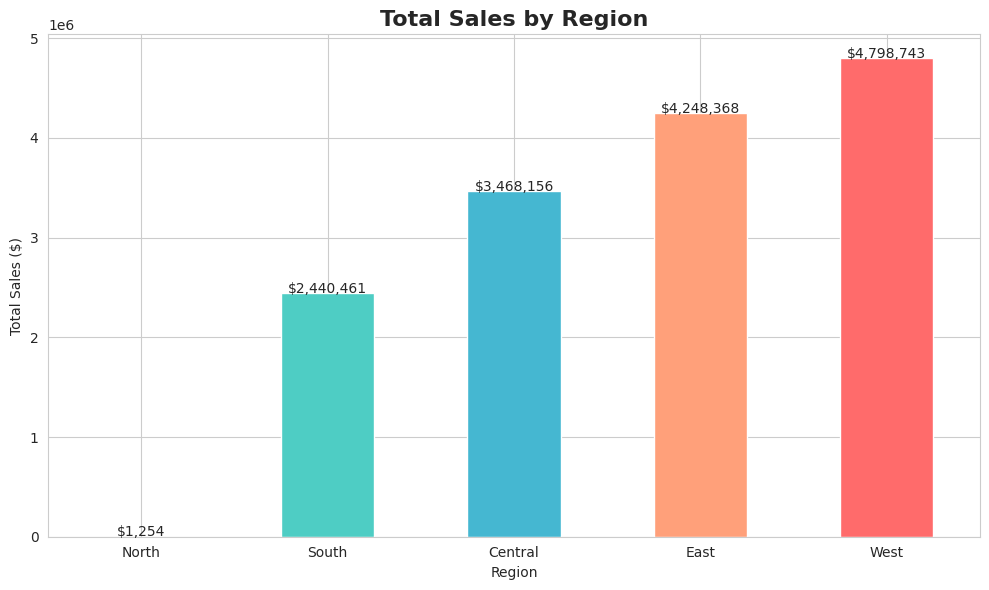

In [13]:
# B. Regional Analysis
# 1. Sales by region
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
region_sales.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
for i, v in enumerate(region_sales):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

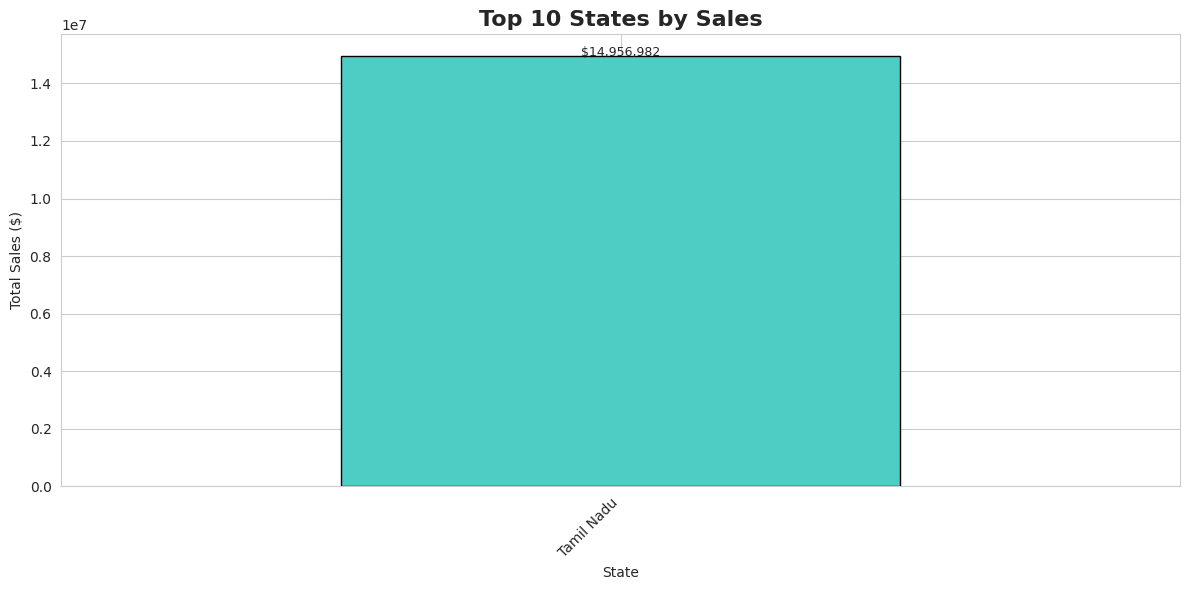

In [33]:
# 2. Sales by state (top 10)
plt.figure(figsize=(12, 6))
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
state_sales.plot(kind='bar', color='#4ECDC4', edgecolor='black')
plt.title('Top 10 States by Sales', fontsize=16, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(state_sales):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

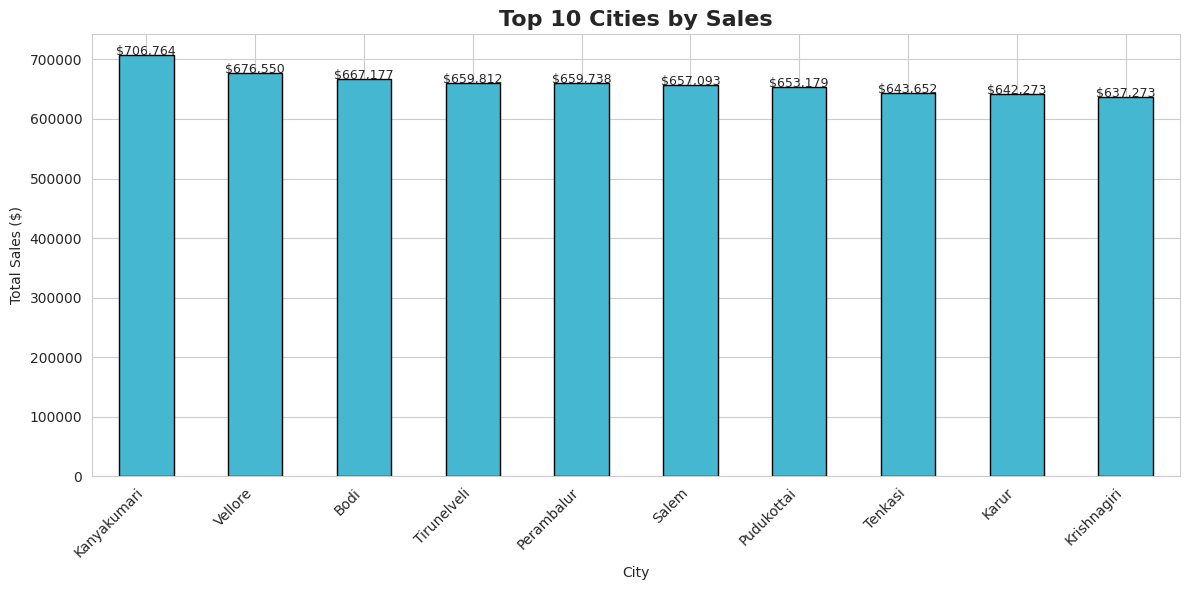

In [15]:
# 3. Sales by city (top 10)
plt.figure(figsize=(12, 6))
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
city_sales.plot(kind='bar', color='#45B7D1', edgecolor='black')
plt.title('Top 10 Cities by Sales', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(city_sales):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

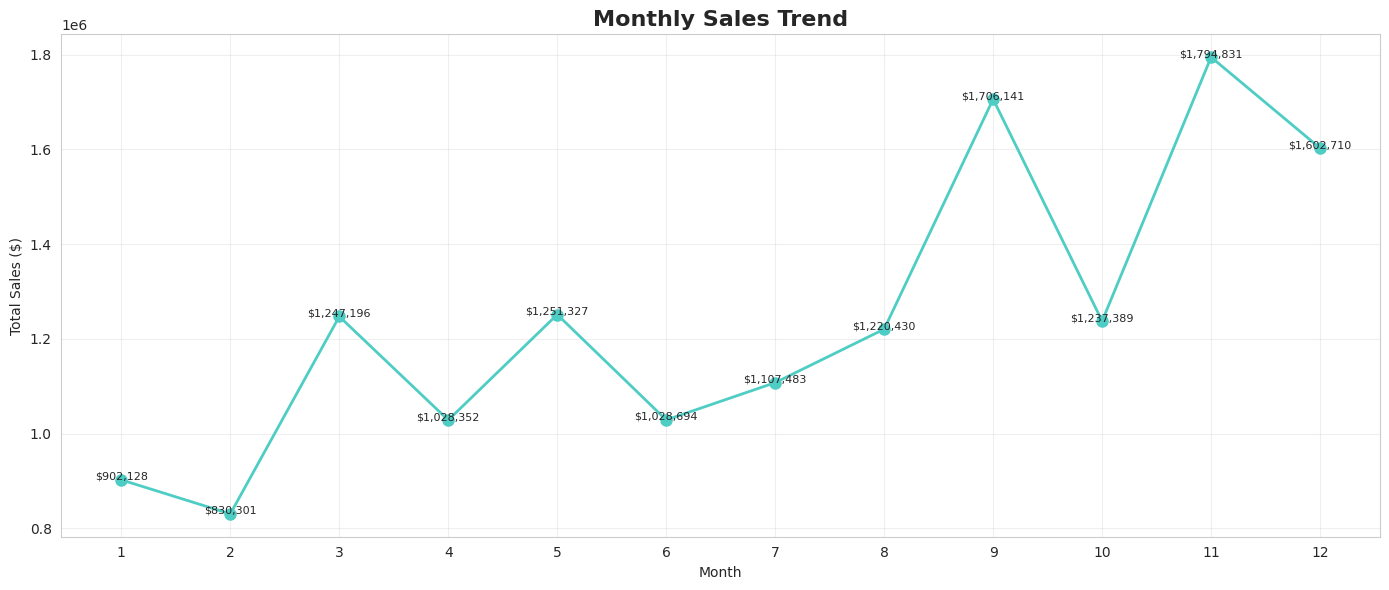

In [16]:
# C. Time-Based Analysis
# 1. Monthly sales trend
plt.figure(figsize=(14, 6))
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line', marker='o', color='#4ECDC4', linewidth=2, markersize=8)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
for i, v in enumerate(monthly_sales):
    plt.text(i + 1, v + 100, f'${v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

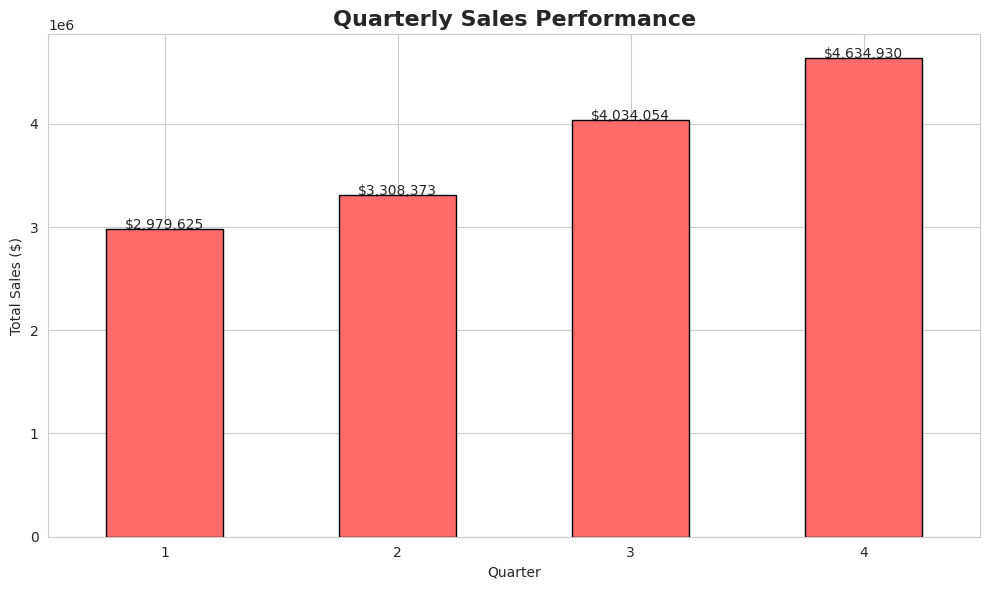

In [17]:
# 2. Quarterly sales
plt.figure(figsize=(10, 6))
quarterly_sales = df.groupby('Quarter')['Sales'].sum()
quarterly_sales.plot(kind='bar', color='#FF6B6B', edgecolor='black')
plt.title('Quarterly Sales Performance', fontsize=16, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
for i, v in enumerate(quarterly_sales):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

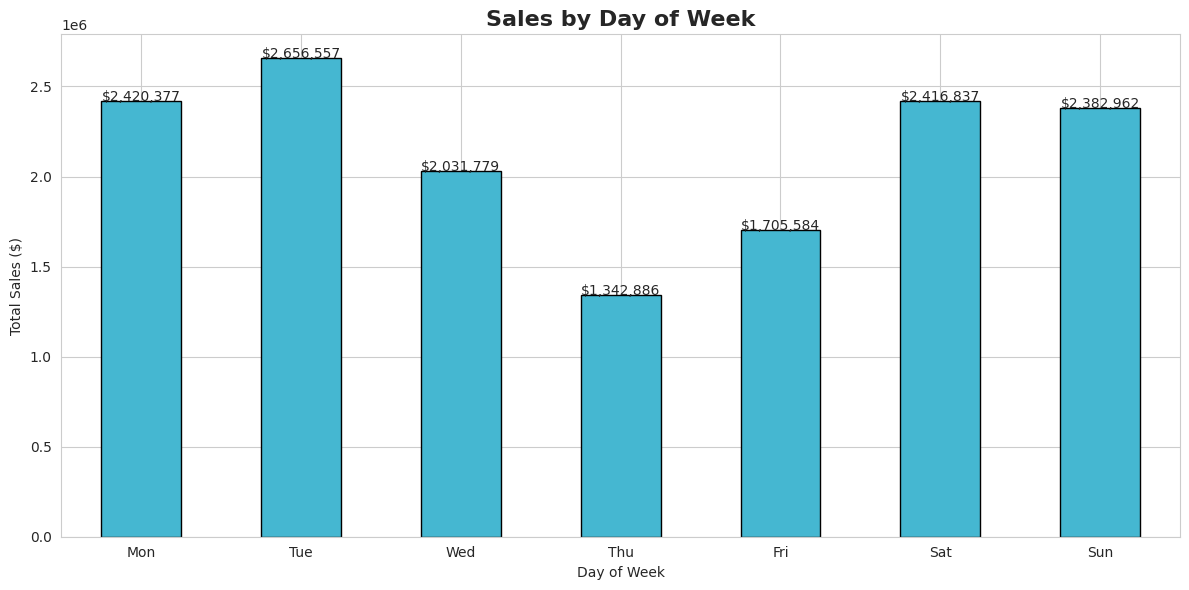

In [18]:
# 3. Sales by day of week
plt.figure(figsize=(12, 6))
day_sales = df.groupby('Day_of_Week')['Sales'].sum()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_sales.index = days
day_sales.plot(kind='bar', color='#45B7D1', edgecolor='black')
plt.title('Sales by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
for i, v in enumerate(day_sales):
    plt.text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

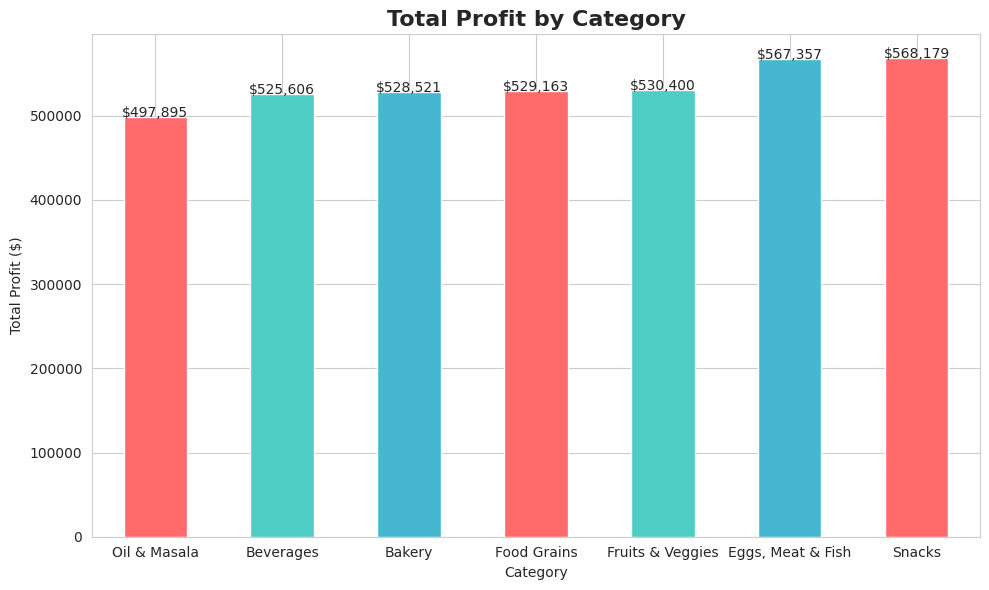

In [36]:
# D. Profit Analysis
# 1. Profit by category
plt.figure(figsize=(10, 6))
category_profit = df.groupby('Category')['Profit'].sum().sort_values()
category_profit.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Total Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=0)
for i, v in enumerate(category_profit):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

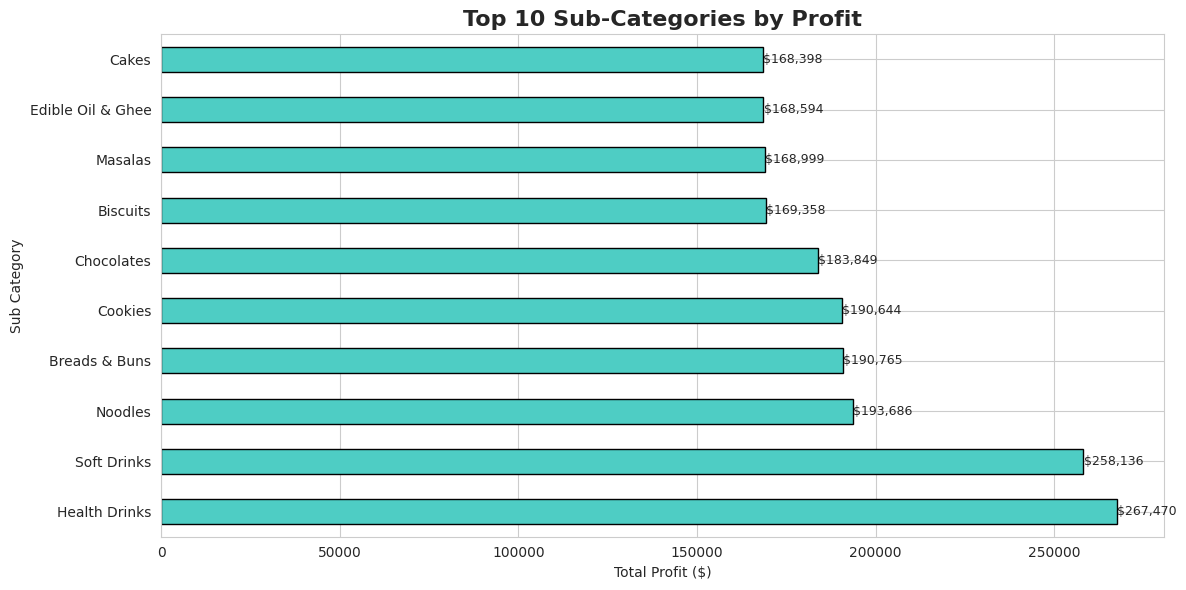

In [20]:
# 2. Profit by sub-category (top 10)
plt.figure(figsize=(12, 6))
sub_category_profit = df.groupby('Sub Category')['Profit'].sum().sort_values(ascending=False).head(10)
sub_category_profit.plot(kind='barh', color='#4ECDC4', edgecolor='black')
plt.title('Top 10 Sub-Categories by Profit', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub Category')
for i, v in enumerate(sub_category_profit):
    plt.text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

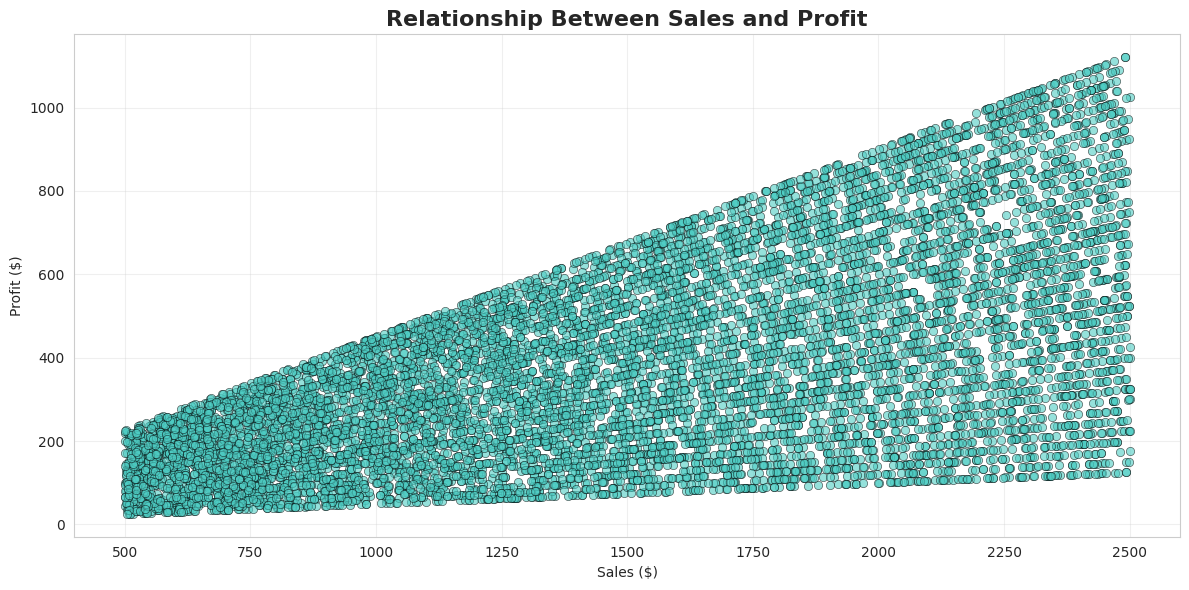

In [21]:
# 3. Sales vs Profit scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df['Sales'], df['Profit'], alpha=0.6, color='#4ECDC4', edgecolors='black', linewidth=0.5)
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.title('Relationship Between Sales and Profit', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

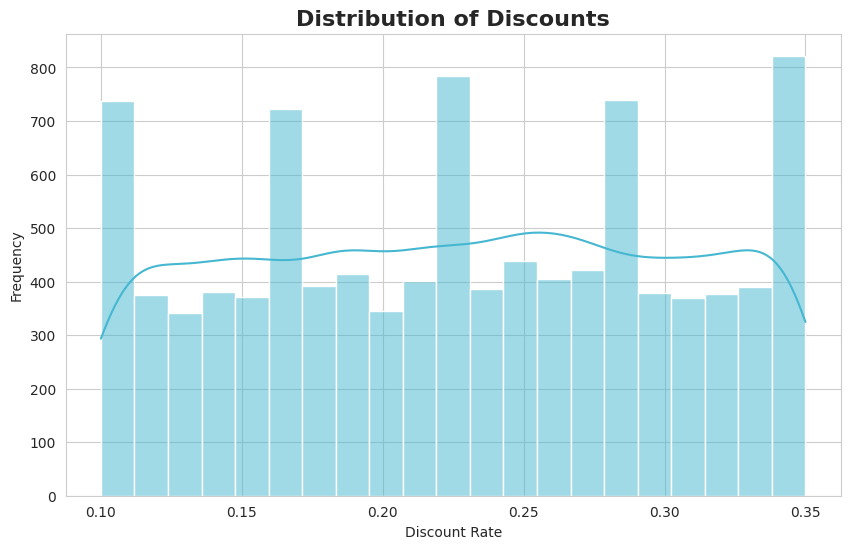

In [22]:
# E. Discount Analysis
# 1. Discount distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Discount'], kde=True, color='#45B7D1')
plt.title('Distribution of Discounts', fontsize=16, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Frequency')
plt.show()

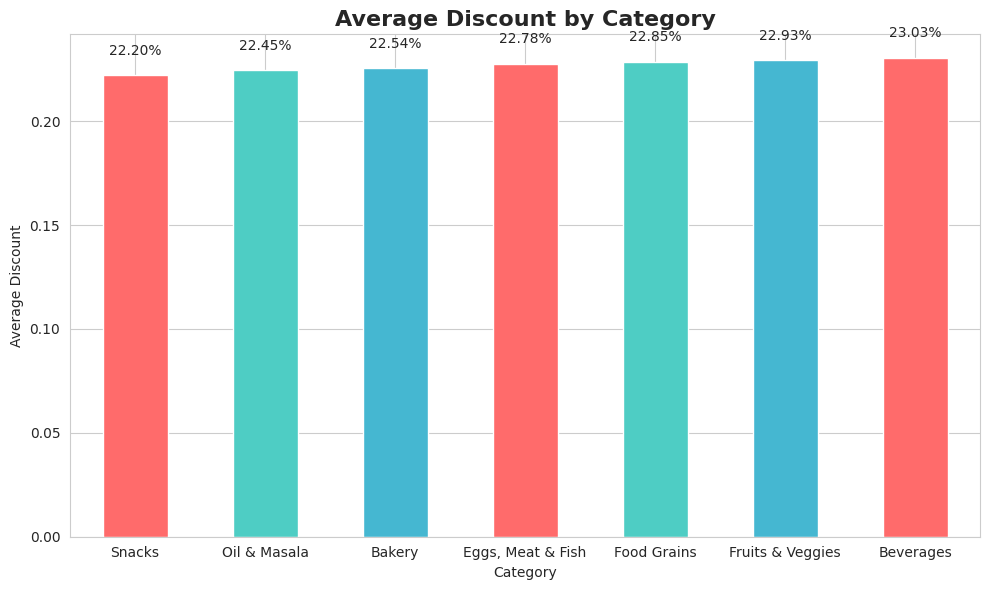

In [23]:
# 2. Average discount by category
plt.figure(figsize=(10, 6))
category_discount = df.groupby('Category')['Discount'].mean().sort_values()
category_discount.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Average Discount by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Discount')
plt.xticks(rotation=0)
for i, v in enumerate(category_discount):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

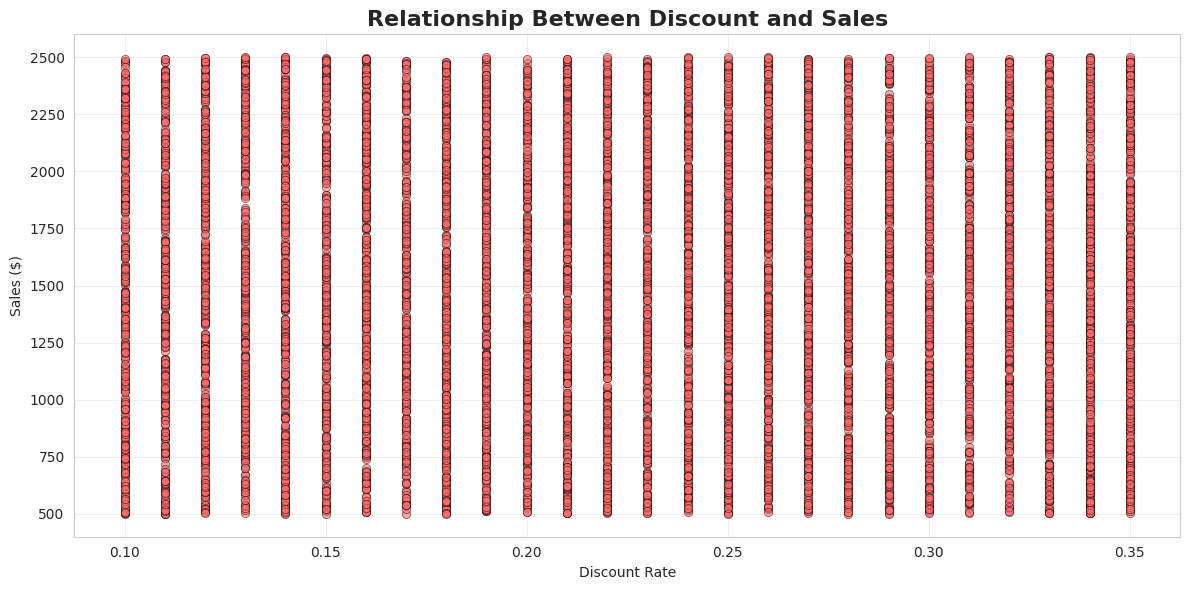

In [24]:
# 3. Sales vs Discount scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df['Discount'], df['Sales'], alpha=0.6, color='#FF6B6B', edgecolors='black', linewidth=0.5)
plt.xlabel('Discount Rate')
plt.ylabel('Sales ($)')
plt.title('Relationship Between Discount and Sales', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

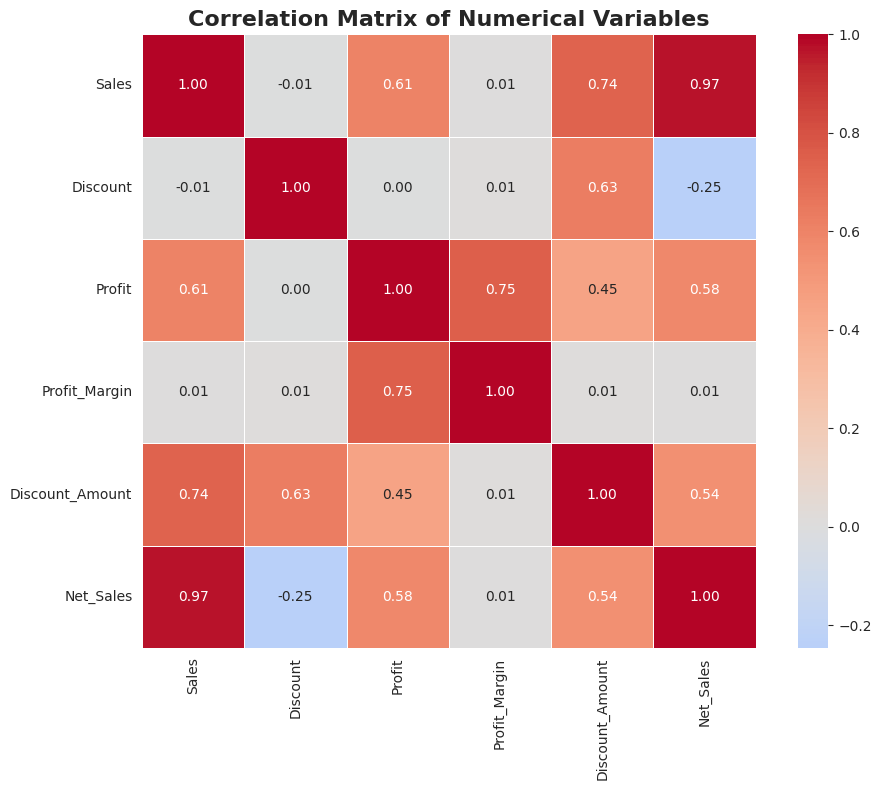

In [25]:
# F. Correlation Analysis
# 1. Numerical columns correlation
numeric_cols = ['Sales', 'Discount', 'Profit', 'Profit_Margin', 'Discount_Amount', 'Net_Sales']
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

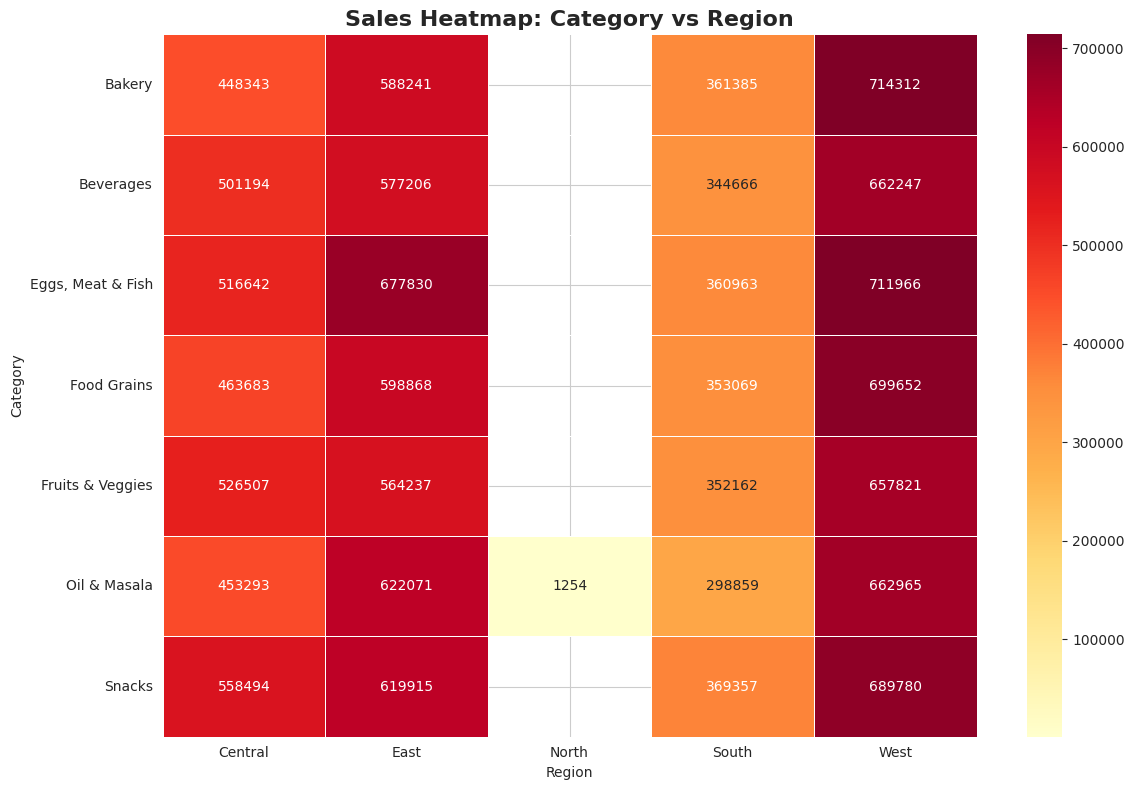

In [26]:
# G. Regional Analysis with Category
# 1. Category sales by region (heatmap)
plt.figure(figsize=(12, 8))
pivot_table = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Sales Heatmap: Category vs Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

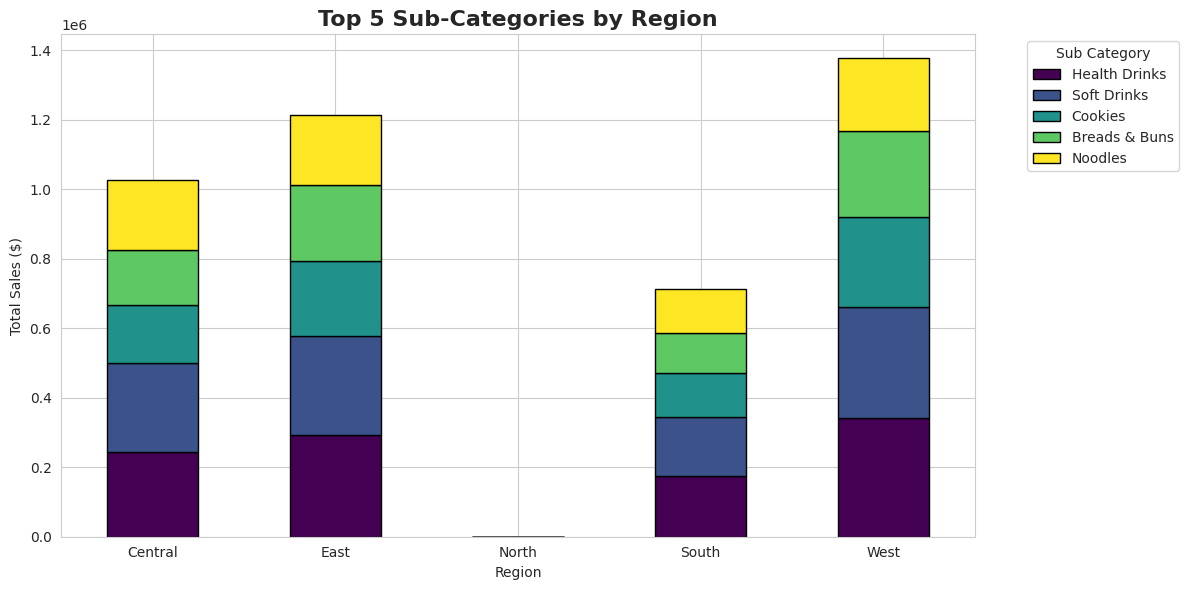

In [27]:
# 2. Sub-category distribution by region
plt.figure(figsize=(14, 8))
sub_category_region = df.groupby(['Region', 'Sub Category'])['Sales'].sum().unstack().fillna(0)
sub_category_region_top = sub_category_region[sub_category_region.sum().nlargest(5).index]
sub_category_region_top.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black')
plt.title('Top 5 Sub-Categories by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.legend(title='Sub Category', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


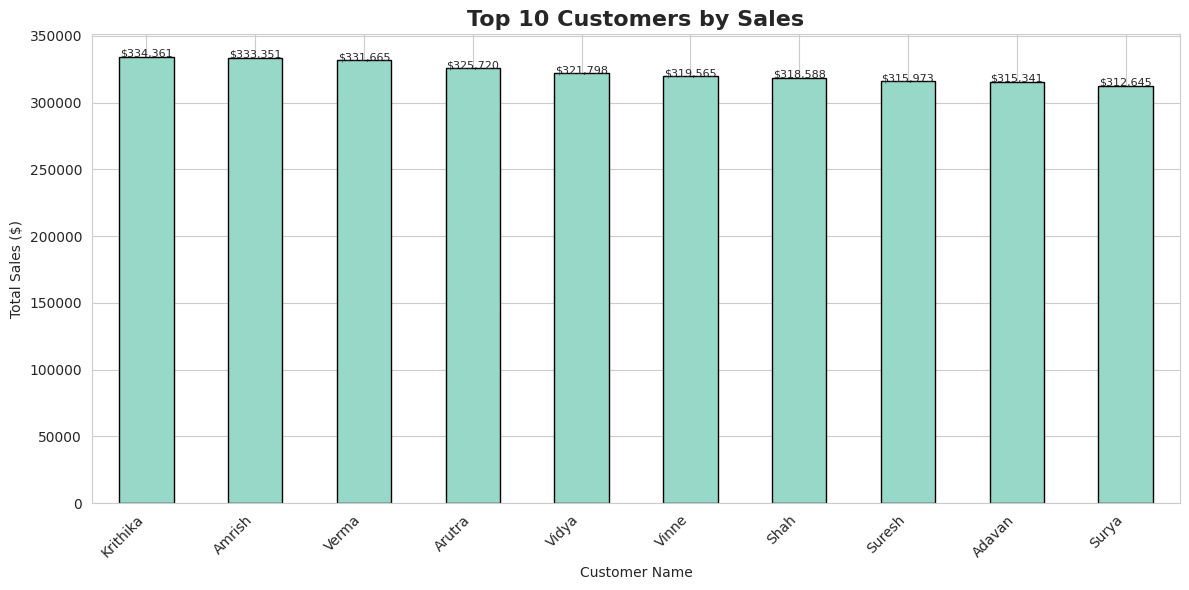

In [28]:
# H. Customer Analysis
# 1. Top customers by sales
plt.figure(figsize=(12, 6))
customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
customer_sales.plot(kind='bar', color='#98D8C8', edgecolor='black')
plt.title('Top 10 Customers by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(customer_sales):
    plt.text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

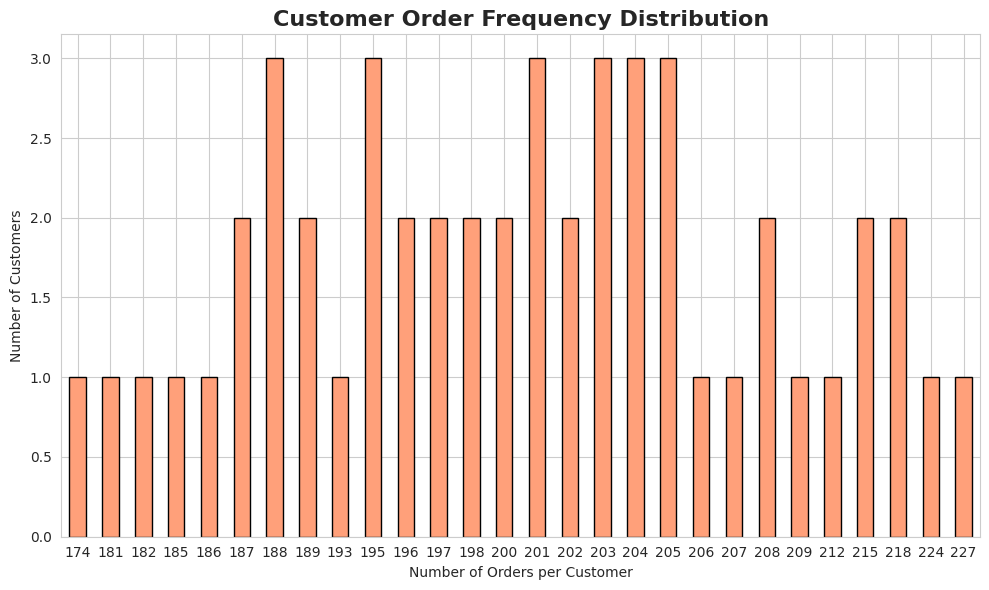

In [29]:
# 2. Customer order frequency
plt.figure(figsize=(10, 6))
order_frequency = df['Customer Name'].value_counts().value_counts().sort_index()
order_frequency.plot(kind='bar', color='#FFA07A', edgecolor='black')
plt.title('Customer Order Frequency Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

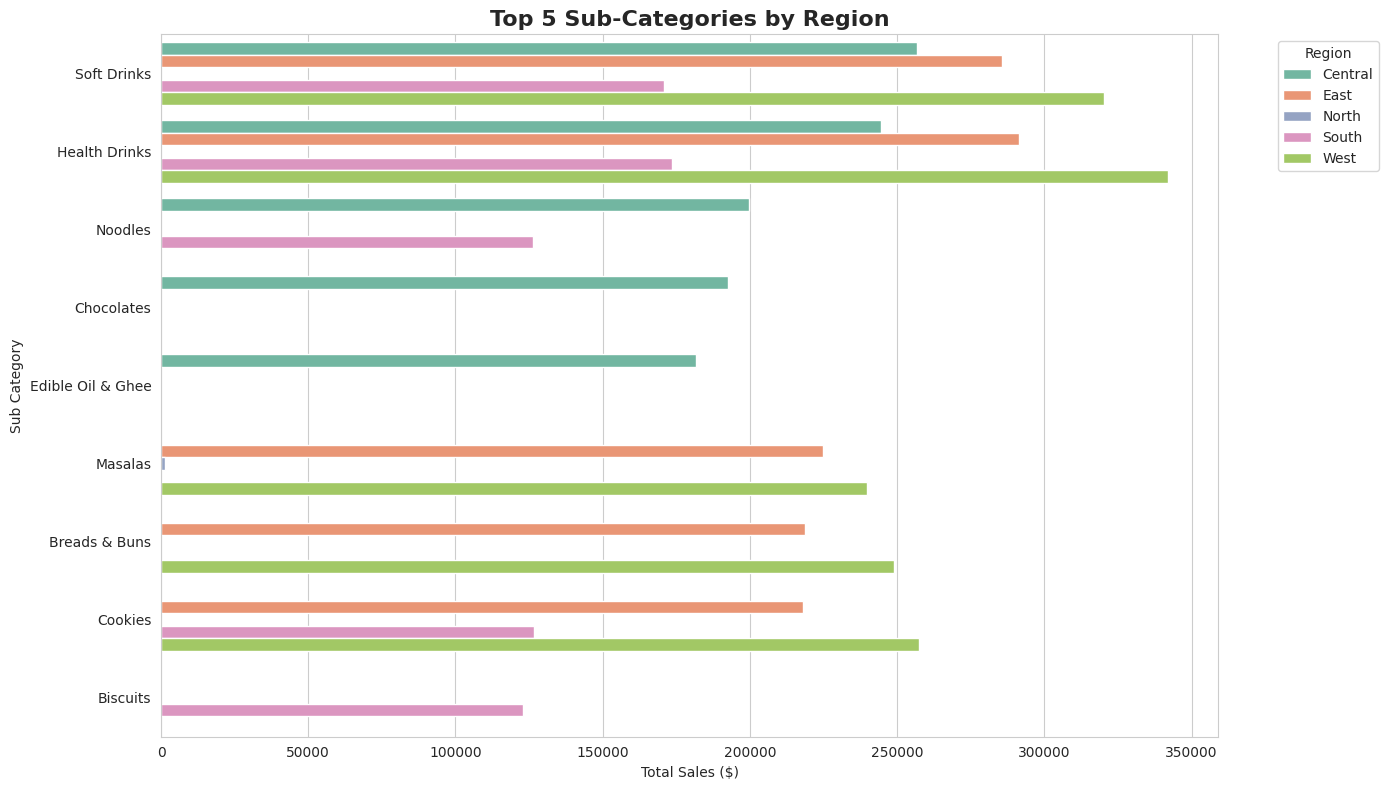

In [30]:
# I. Additional Analysis - Top Selling Sub-Categories by Region
plt.figure(figsize=(14, 8))
top_sub_by_region = df.groupby(['Region', 'Sub Category']).agg({
    'Sales': 'sum'
}).reset_index().sort_values(['Region', 'Sales'], ascending=[True, False])
top_sub_by_region_top = top_sub_by_region.groupby('Region').head(5)
sns.barplot(data=top_sub_by_region_top, x='Sales', y='Sub Category', hue='Region', palette='Set2')
plt.title('Top 5 Sub-Categories by Region', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub Category')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## SUMMARY AND CONCLUSIONS



In [31]:
print("\n\n")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")
print("="*60)
print("SUPERMARKET SALES ANALYSIS - EXECUTIVE SUMMARY")
print("="*60)

print(f"\n1. Overall Performance:")
print(f"   Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"   Total Profit: ${df['Profit'].sum():,.2f}")
print(f"   Average Order Value: ${df['Sales'].mean():.2f}")
print(f"   Total Orders: {len(df):,}")
print(f"   Average Profit Margin: {df['Profit_Margin'].mean():.2f}%")
print(f"   Total Discount Given: ${df['Discount_Amount'].sum():,.2f}")

print(f"\n2. Category Performance:")
category_perf = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
for category, sales in category_perf.items():
    profit = df[df['Category'] == category]['Profit'].sum()
    print(f"   {category}: Sales ${sales:,.2f}, Profit ${profit:,.2f}")

print(f"\n3. Top 5 Sub-Categories by Sales:")
sub_category_perf = df.groupby('Sub Category')['Sales'].sum().sort_values(ascending=False).head(5)
for sub_cat, sales in sub_category_perf.items():
    profit = df[df['Sub Category'] == sub_cat]['Profit'].sum()
    print(f"   {sub_cat}: Sales ${sales:,.2f}, Profit ${profit:,.2f}")

print(f"\n4. Regional Performance:")
region_perf = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
for region, sales in region_perf.items():
    profit = df[df['Region'] == region]['Profit'].sum()
    print(f"   {region}: Sales ${sales:,.2f}, Profit ${profit:,.2f}")

print(f"\n5. Top 5 States by Sales:")
state_perf = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
for state, sales in state_perf.items():
    print(f"   {state}: ${sales:,.2f}")

print(f"\n6. Top 5 Cities by Sales:")
city_perf = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(5)
for city, sales in city_perf.items():
    print(f"   {city}: ${sales:,.2f}")

print(f"\n7. Best Performing Quarter:")
quarter_perf = df.groupby('Quarter')['Sales'].sum().sort_values(ascending=False)
for quarter, sales in quarter_perf.items():
    print(f"   Q{quarter}: ${sales:,.2f} ({sales/df['Sales'].sum()*100:.1f}%)")

print(f"\n8. Discount Analysis:")
print(f"   Average Discount Rate: {df['Discount'].mean():.2%}")
print(f"   Maximum Discount Rate: {df['Discount'].max():.2%}")
print(f"   Most Discounted Category: {df.groupby('Category')['Discount'].mean().idxmax()} ({df.groupby('Category')['Discount'].mean().max():.2%})")
print(f"   Least Discounted Category: {df.groupby('Category')['Discount'].mean().idxmin()} ({df.groupby('Category')['Discount'].mean().min():.2%})")

print(f"\n9. Profitability Analysis:")
print(f"   Highest Profit Category: {df.groupby('Category')['Profit'].sum().idxmax()} (${df.groupby('Category')['Profit'].sum().max():,.2f})")
print(f"   Lowest Profit Category: {df.groupby('Category')['Profit'].sum().idxmin()} (${df.groupby('Category')['Profit'].sum().min():,.2f})")

print(f"\n10. Correlation Insights:")
print(f"    Sales vs Profit Correlation: {df['Sales'].corr(df['Profit']):.3f}")
print(f"    Sales vs Discount Correlation: {df['Sales'].corr(df['Discount']):.3f}")
print(f"    Discount vs Profit Correlation: {df['Discount'].corr(df['Profit']):.3f}")

print(f"\n11. Customer Insights:")
print(f"    Total Unique Customers: {df['Customer Name'].nunique():,}")
print(f"    Average Orders per Customer: {len(df) / df['Customer Name'].nunique():.2f}")
top_customer = df.groupby('Customer Name')['Sales'].sum().idxmax()
top_customer_sales = df.groupby('Customer Name')['Sales'].sum().max()
print(f"    Top Customer: {top_customer} (${top_customer_sales:,.2f})")

print("----------------------------------------------------------------------------------------------------------------------------------------------------")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")




----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------
SUPERMARKET SALES ANALYSIS - EXECUTIVE SUMMARY

1. Overall Performance:
   Total Revenue: $14,956,982.00
   Total Profit: $3,747,121.20
   Average Order Value: $1496.60
   Total Orders: 9,994
   Average Profit Margin: 25.02%
   Total Discount Given: $3,390,124.55

2. Category Performance:
   Eggs, Meat & Fish: Sales $2,267,401.00, Profit $567,357.22
   Snacks: Sales $2,237,546.00, Profit $568,178.85
   Food Grains: Sales $2,115,272.00, Profit $529,162.64
   Bakery: Sales $2,112,281.00, Profit $528,521.06
   Fruits & Veggies: Sales $2,100,727.00, Profit $530,400.38
   Beverages: Sales $2,085,313.00, Profit $525,605.76
   Oil & Masala: Sales $2,038,442.00, Profit $497,895.29

3. Top 5 Sub-Cat